In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\Natural_Gas_data.csv"
df = pd.read_csv(folder_path) 

print(df.head())
print(df.info)

         date  open   high   low  close  volume
0  2000-08-30  4.65  4.815  4.63  4.805   34954
1  2000-08-31  4.82  4.870  4.74  4.780   25787
2  2000-09-01  4.75  4.860  4.75  4.835     113
3  2000-09-05  4.85  4.975  4.84  4.960   26096
4  2000-09-06  4.99  5.110  4.96  5.065   32764
<bound method DataFrame.info of             date   open   high    low  close  volume
0     2000-08-30  4.650  4.815  4.630  4.805   34954
1     2000-08-31  4.820  4.870  4.740  4.780   25787
2     2000-09-01  4.750  4.860  4.750  4.835     113
3     2000-09-05  4.850  4.975  4.840  4.960   26096
4     2000-09-06  4.990  5.110  4.960  5.065   32764
...          ...    ...    ...    ...    ...     ...
5975  2024-06-17  2.846  2.848  2.759  2.788  152241
5976  2024-06-18  2.772  2.916  2.772  2.909  147414
5977  2024-06-20  2.903  2.948  2.723  2.741  186686
5978  2024-06-21  2.725  2.770  2.672  2.705   79372
5979  2024-06-24  2.670  2.834  2.635  2.811   79372

[5980 rows x 6 columns]>


In [10]:
# Kiểm tra min, max date
print("Ngày đầu tiên:", df['date'].min())
print("Ngày cuối cùng:", df['date'].max())

Ngày đầu tiên: 2000-08-30
Ngày cuối cùng: 2024-06-24


In [11]:

# Tạo chuỗi thời gian đầy đủ
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')

# Tìm các ngày bị thiếu
missing_dates = date_range.difference(df['date'])

# In ra các ngày bị thiếu
print("Các ngày bị thiếu trong dataset:")
print(missing_dates)

Các ngày bị thiếu trong dataset:
DatetimeIndex(['2000-08-30', '2000-08-31', '2000-09-01', '2000-09-02',
               '2000-09-03', '2000-09-04', '2000-09-05', '2000-09-06',
               '2000-09-07', '2000-09-08',
               ...
               '2024-06-15', '2024-06-16', '2024-06-17', '2024-06-18',
               '2024-06-19', '2024-06-20', '2024-06-21', '2024-06-22',
               '2024-06-23', '2024-06-24'],
              dtype='datetime64[ns]', length=8700, freq='D')


In [7]:

date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')

missing_dates = date_range.difference(df['date'])

missing_dates_df = pd.DataFrame({'missing_dates': missing_dates})

missing_dates_df.to_csv('missing_dates_.csv', index=False)

print("Các ngày bị thiếu đã được lưu vào file 'missing_dates.csv'")

Các ngày bị thiếu đã được lưu vào file 'missing_dates.csv'


In [5]:
# 3. Xử lý cột ngày tháng
df['date'] = pd.to_datetime(df['date'])

# Set Date làm index
df.set_index('date', inplace=True)

In [6]:
# 5. Kiểm tra missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [7]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau
if df.index.name == 'date':
    df.reset_index(inplace=True)

In [9]:
df.describe()

,date,open,high,low,close,volume
count,5980,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000
mean,2012-08-02 13:11:45.551839488,4.473549,4.579886,4.365687,4.468276,102846.481605
min,2000-08-30 00:00:00,1.441000,1.567000,1.432000,1.482000,0.000000
25%,2006-08-27 06:00:00,2.800750,2.852000,2.743000,2.797000,45950.000000
50%,2012-08-01 12:00:00,3.837500,3.922000,3.761000,3.828500,98166.000000
75%,2018-07-16 06:00:00,5.658250,5.793750,5.510000,5.646250,145383.500000
max,2024-06-24 00:00:00,15.160000,15.780000,14.851000,15.378000,459196.000000
std,NaN,2.248934,2.312086,2.187833,2.247718,63233.577171


In [12]:
df.head(5)

,date,open,high,low,close,volume
0,2000-08-30,4.65,4.815,4.63,4.805,34954
1,2000-08-31,4.82,4.870,4.74,4.780,25787
2,2000-09-01,4.75,4.860,4.75,4.835,113
3,2000-09-05,4.85,4.975,4.84,4.960,26096
4,2000-09-06,4.99,5.110,4.96,5.065,32764


In [13]:
columns = ['date', 'open', 'high', 'low', 'close', 'volume']
for col in columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (df[col] <= 0).sum())
    else:
        print(f"Cột {col} không phải số, bỏ qua.")


Cột date không phải số, bỏ qua.
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 9


In [14]:


# Tạo chuỗi thời gian đầy đủ
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')

# Tạo DataFrame mới với các ngày đầy đủ
full_dates = pd.DataFrame({'date': date_range})

# Hợp nhất với DataFrame hiện tại
df = pd.merge(full_dates, df, on='date', how='left')

# Kiểm tra kết quả
print(df.head())
print("Số lượng giá trị bị thiếu sau khi thêm ngày:", df.isnull().sum())

        date  open   high   low  close   volume
0 2000-08-30  4.65  4.815  4.63  4.805  34954.0
1 2000-08-31  4.82  4.870  4.74  4.780  25787.0
2 2000-09-01  4.75  4.860  4.75  4.835    113.0
3 2000-09-02   NaN    NaN   NaN    NaN      NaN
4 2000-09-03   NaN    NaN   NaN    NaN      NaN
Số lượng giá trị bị thiếu sau khi thêm ngày: date         0
open      2720
high      2720
low       2720
close     2720
volume    2720
dtype: int64


In [ ]:
for col in ['open', 'high', 'low', 'close']:
    df[col] = df[col].apply(lambda x: x if x > 0 else df.interpolate(method='linear', inplace=True)())  # Thay bằng giá trị trung bình của cột


In [23]:

df['volume'] = df['volume'].apply(lambda x: x if x >= 0 else df[col].mean())  # Thay bằng giá trị trung bình của cột


In [17]:
print("Số lượng giá trị bị thiếu sau khi thêm ngày:", df.isnull().sum())

Số lượng giá trị bị thiếu sau khi thêm ngày: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [18]:
df.describe()

,date,open,high,low,close,volume
count,8700,8700.000000,8700.000000,8700.000000,8700.000000,8700.000000
mean,2012-07-27 12:00:00,4.473549,4.579886,4.365687,4.468276,70693.576289
min,2000-08-30 00:00:00,1.441000,1.567000,1.432000,1.482000,0.000000
25%,2006-08-13 18:00:00,3.150000,3.215000,3.075250,3.141000,4.468276
50%,2012-07-27 12:00:00,4.473549,4.579886,4.365687,4.468276,49198.000000
75%,2018-07-11 06:00:00,4.598250,4.695000,4.489250,4.580250,124070.500000
max,2024-06-24 00:00:00,15.160000,15.780000,14.851000,15.378000,459196.000000
std,NaN,1.864474,1.916830,1.813818,1.863466,70861.568604


In [8]:
# Kiểm tra min, max date
print("Ngày đầu tiên:", df['date'].min())
print("Ngày cuối cùng:", df['date'].max())


Ngày đầu tiên: 2000-08-30
Ngày cuối cùng: 2024-06-24


In [20]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau
if df.index.name == 'date':
    df.reset_index(inplace=True)

C:\Users\15520\AppData\Local\Temp\ipykernel_12856\2289552976.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


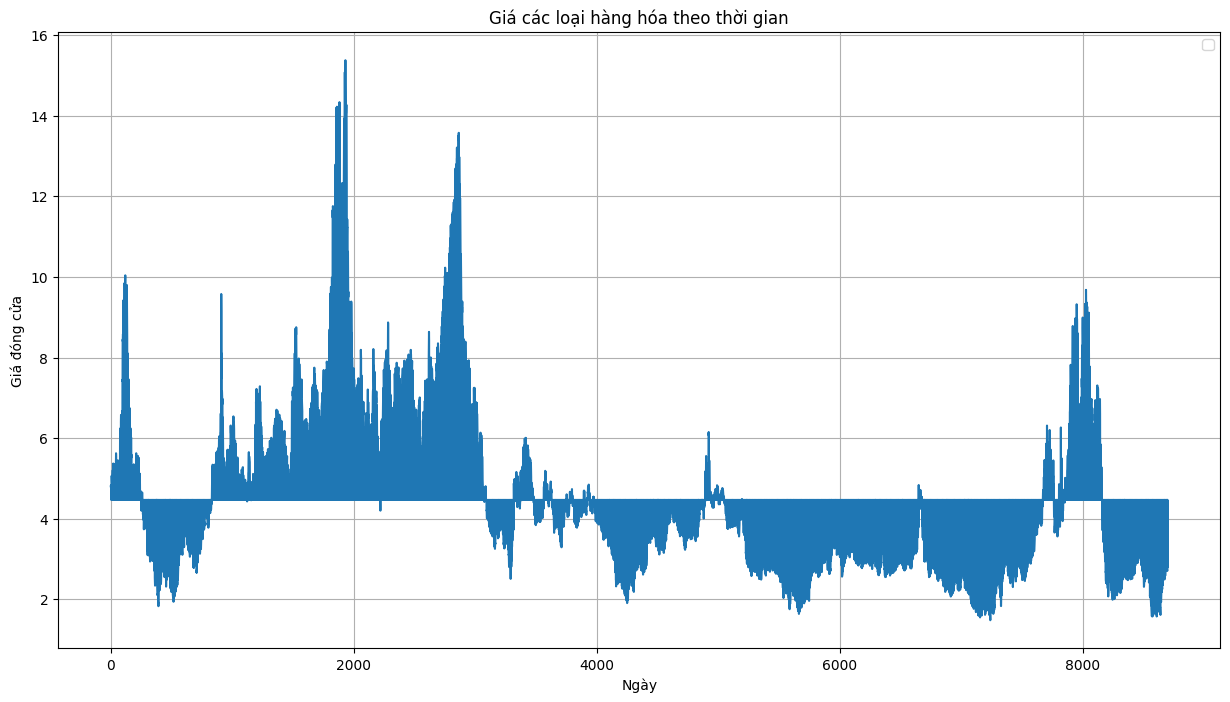

In [22]:
import matplotlib.pyplot as plt

# Vẽ tất cả các commodity trên cùng một biểu đồ
plt.figure(figsize=(15, 8))

plt.plot(df.index, df['close'])  # giả sử cột giá cần vẽ là 'Close'

plt.title('Giá các loại hàng hóa theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.grid(True)
plt.show()


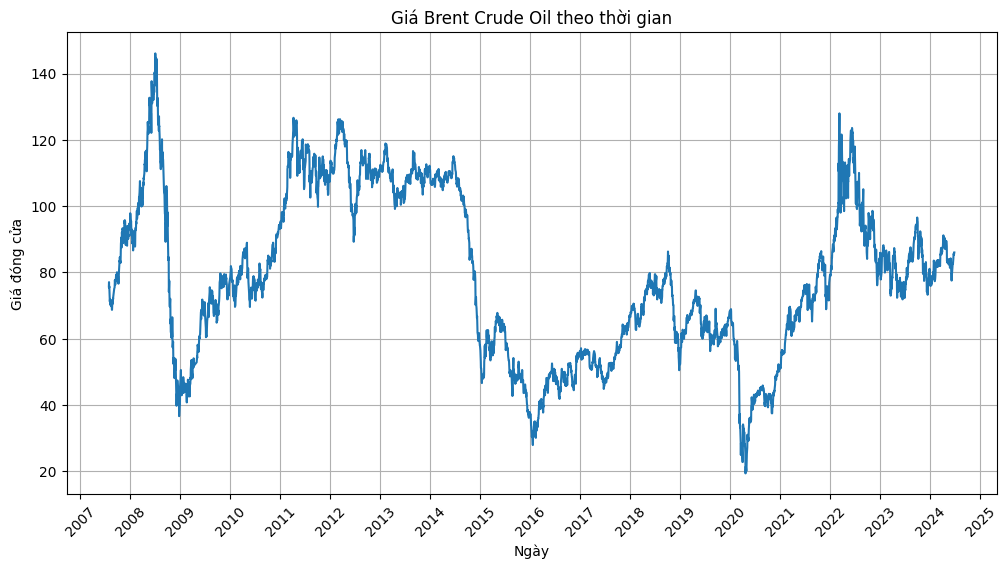

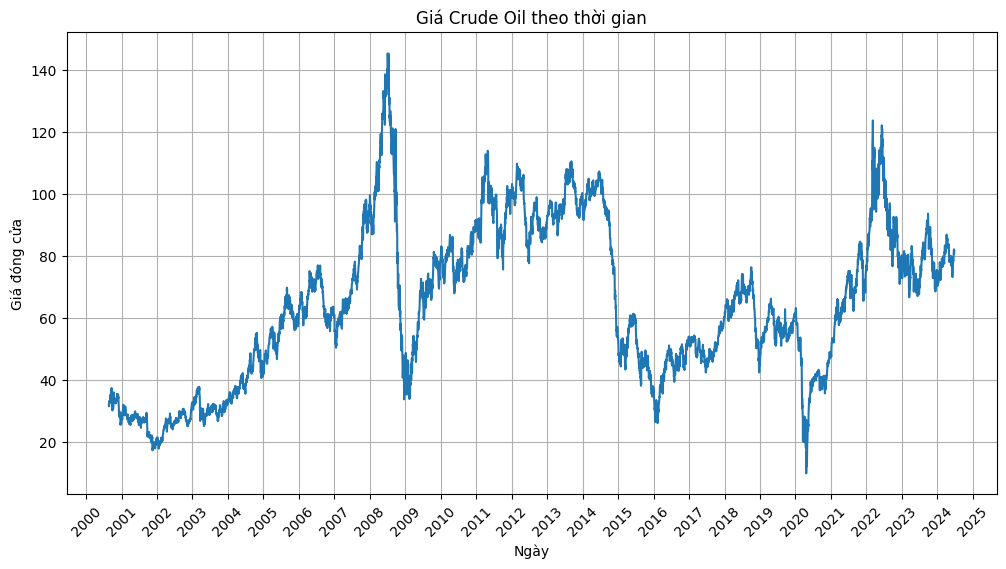

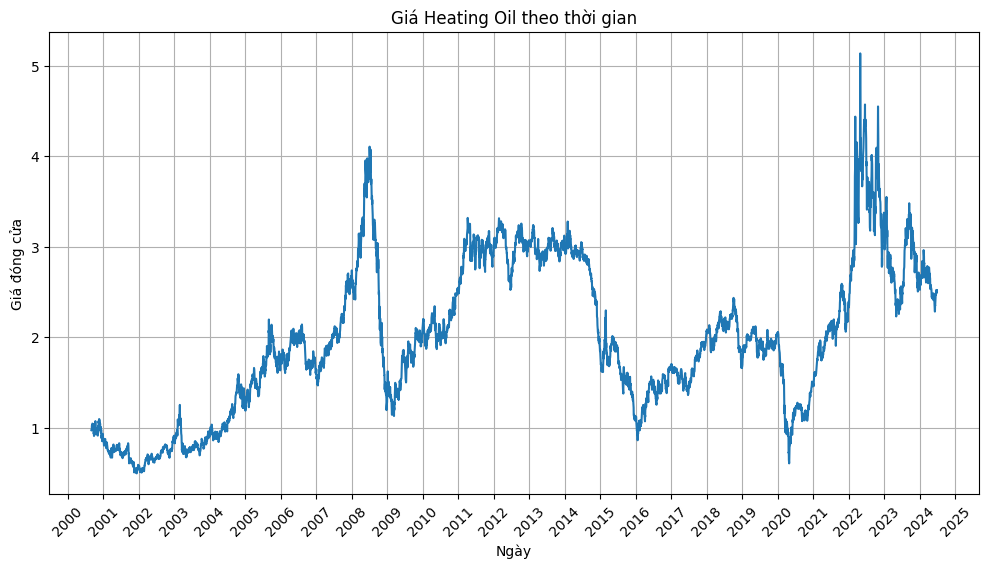

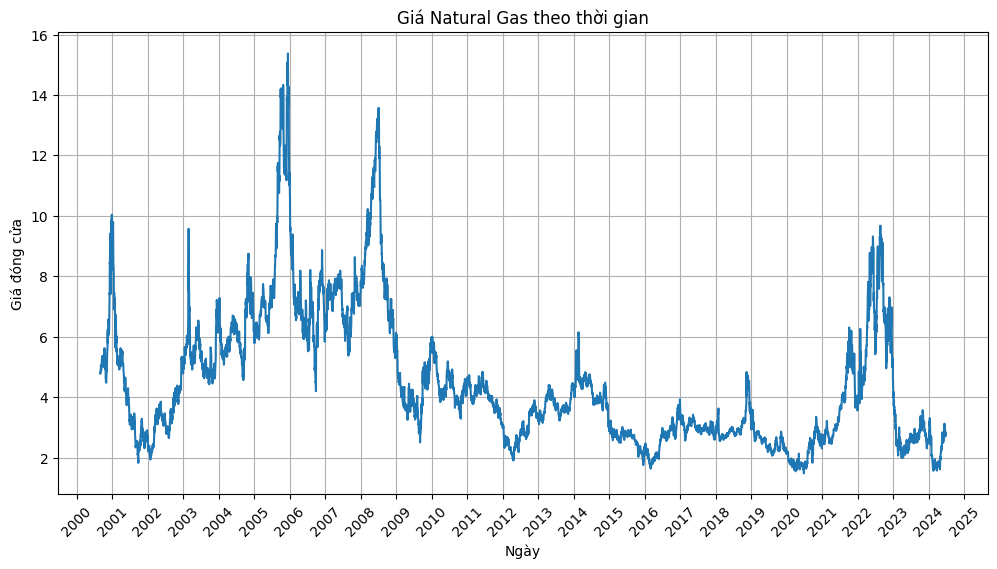

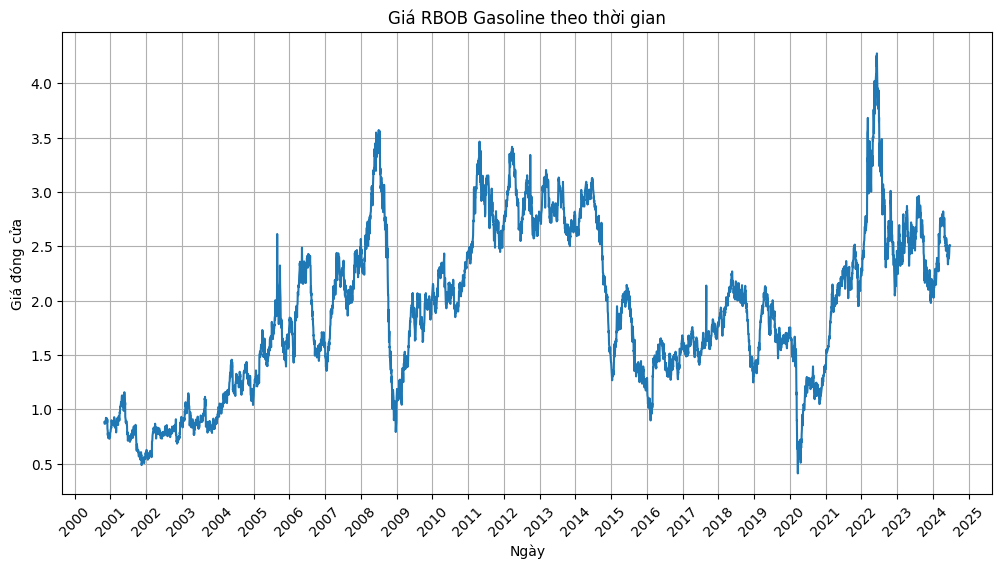

In [45]:
import matplotlib.dates as mdates

for comm, df_comm in series_dict.items():
    plt.figure(figsize=(12, 6))
    plt.plot(df_comm.index, df_comm['close'])
    plt.title(f'Giá {comm} theo thời gian')
    plt.xlabel('Ngày')
    plt.ylabel('Giá đóng cửa')
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
# tiếp tục làm các bước xử lý cần thiết cho mô hình - phương pháp dự báo cần sử dụng